In [148]:
from dotenv import load_dotenv
load_dotenv()

True

In [149]:
from langgraph.graph import StateGraph, START,END
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [150]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [151]:
class MailState(BaseModel):
    query :str = ""
    draft : str = ""
    human_feedback : str =""
    final_response : str =""
    

In [152]:
def DraftEmailNode(state : MailState) -> MailState:
    if state.human_feedback:
        draft = llm.invoke(f"""
                            rewrite this draft email for {state.query},
                            you have genereated this email : {state.draft},
                            human feedback to apply : {state.human_feedback}, 
                            
                                """).content
    else:
        draft = llm.invoke(state.query).content
    state.draft= draft
    return state

def HumanFeedbackNode(state: MailState) -> MailState:
    feedback = interrupt({
        "draft_email":state.draft,
        "question": "do you want to continue with this email or want me to re-write this one again?"
    })

    fb = (feedback or "").strip().lower()
    if fb in ("approved","okay","ok","yes"):
        state.human_feedback=""
        return state
    else:
        state.human_feedback = feedback
        return state

def finalizeNode (state:MailState)->MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("email send Successfully")
        state.final_response = "Email sent Successfully"
        return state

def condition_route(state: MailState) -> Literal["draft","final"]:
    if state.human_feedback:
        return "draft"
    return "final"

In [153]:
graph_builder = StateGraph(MailState)

graph_builder.add_node("draft", DraftEmailNode)
graph_builder.add_node("human_fb", HumanFeedbackNode)
graph_builder.add_node("final", finalizeNode)


graph_builder.add_edge(START,"draft")
graph_builder.add_edge("draft","human_fb")
graph_builder.add_conditional_edges("human_fb",condition_route)
graph_builder.add_edge("final",END)


graph=graph_builder.compile(checkpointer=InMemorySaver())


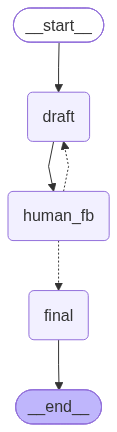

In [154]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [155]:
config = {"configurable": {"thread_id":"1"}}


In [156]:
res = graph.invoke({"query":"i want to send email for medical leave to my hr, dates will be 10th august to  15th august 2026, so creata a simple mail"},config=config )

In [157]:
print(res["draft"])

**Subject:** Request for Medical Leave (10 – 15 August 2026)

Dear [HR Manager’s Name],

I hope you are well. I am writing to formally request medical leave from **10 August 2026 to 15 August 2026**. I will be under medical care during this period and will provide a medical certificate upon my return.

I have ensured that all urgent tasks are delegated and that my current projects will be on hold until my return. Please let me know if you need any additional information or documentation.

Thank you for your understanding and support.

Kind regards,

[Your Full Name]  
[Your Job Title]  
[Department]  
[Phone Number]  
[Email Address]


In [158]:
res = graph.invoke(Command(resume="i want to change dates, and new dates are 7july to 21 july, and i want to remove the place holders and just say thank you"),config=config)

In [160]:
print(res["draft"])

**Subject:** Request for Medical Leave (7 – 21 July 2026)

Dear HR Team,

I would like to request medical leave from **7 July 2026 to 21 July 2026**. I will provide a medical certificate upon my return. Thank you.


In [161]:
res = graph.invoke(Command(resume="yes"),config=config)

email send Successfully
